In [5]:

import dask.dataframe as dd
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')


pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8')

In [9]:

print("Загрузка данных...")
df = dd.read_parquet('./card_transactions/*.parquet')
print(df.shape)
print("=== ИССЛЕДОВАНИЕ ДАННЫХ ===")
print(f"Колонки: {df.columns.tolist()}")
print(f"Размер: {len(df):,} строк")
print(f"Количество партиций: {df.npartitions}")


possible_id_columns = [col for col in df.columns if 'client' in col.lower() or 'id' in col.lower() or 'user' in col.lower()]
print(f"\nВозможные столбцы с ID: {possible_id_columns}")

if possible_id_columns:
    client_id_column = possible_id_columns[0]
else:
    client_id_column = df.columns[0]

print(f"Используем столбец: {client_id_column}")


print("\nПервые 5 строк:")
display(df.head())

Загрузка данных...
(<dask_expr.expr.Scalar: expr=ReadParquetFSSpec(9f65c57).size() // 18, dtype=int64>, 18)
=== ИССЛЕДОВАНИЕ ДАННЫХ ===
Колонки: ['amnt', 'currency', 'operation_kind', 'card_type', 'operation_type', 'operation_type_group', 'ecommerce_flag', 'payment_system', 'income_flag', 'mcc', 'country', 'city', 'mcc_category', 'day_of_week', 'hour', 'weekofyear', 'hour_diff', 'client_id']
Размер: 270,450,065 строк
Количество партиций: 50

Возможные столбцы с ID: ['client_id']
Используем столбец: client_id

Первые 5 строк:


,amnt,currency,operation_kind,card_type,operation_type,operation_type_group,ecommerce_flag,payment_system,income_flag,mcc,country,city,mcc_category,day_of_week,hour,weekofyear,hour_diff,client_id
0,0.465425,1,4,98,4,2,3,7,3,2,1,37,2,4,19,34,-1,5feceb
1,0.000000,1,2,98,7,1,3,7,3,2,1,49,2,4,20,34,0,5feceb
2,0.521152,1,2,98,3,1,3,7,3,2,1,37,2,4,20,34,0,5feceb
3,0.356078,1,1,5,2,1,3,7,3,10,1,49,7,2,0,34,52,5feceb
4,0.000000,1,2,98,7,1,3,7,3,2,1,49,2,4,16,53,280,5feceb


In [10]:
# Базовые агрегации
print("Создание базовых признаков...")

basic_stats = df.groupby(client_id_column).agg({
    'amnt': ['mean', 'sum', 'count'],
    'hour_diff': 'mean'
}).compute()

basic_stats.columns = ['mean_amount', 'total_amount', 'transaction_count', 'hour_diff_mean']

print(f"Базовые признаки созданы: {basic_stats.shape}")
display(basic_stats.head())

Создание базовых признаков...
Базовые признаки созданы: (936619, 4)


,mean_amount,total_amount,transaction_count,hour_diff_mean
client_id,,,,
5feceb,0.386645,69.982751,181,44.613260
6b86b2,0.335351,119.384783,356,24.053371
d4735e,0.306107,70.098407,229,36.655022
4e0740,0.330808,22.164130,67,109.104478
4b2277,0.356631,107.345889,301,55.684385


In [11]:
# Категориальные признаки - количество уникальных значений
print("Создание категориальных признаков...")

categorical_features = {}

# Список категориальных колонок для анализа
cat_columns = ['currency', 'operation_kind', 'card_type', 'operation_type_group', 
               'payment_system', 'mcc', 'country', 'city']

# Оставляем только существующие колонки
existing_cat_columns = [col for col in cat_columns if col in df.columns]
print(f"Анализируемые категориальные колонки: {existing_cat_columns}")

for col in existing_cat_columns:
    print(f"Обработка {col}...")
    try:
        unique_count = df[[client_id_column, col]].drop_duplicates().groupby(client_id_column)[col].count().compute()
        categorical_features[f'{col}_count'] = unique_count
    except Exception as e:
        print(f"Ошибка при обработке {col}: {e}")

print("Категориальные признаки созданы")

Создание категориальных признаков...
Анализируемые категориальные колонки: ['currency', 'operation_kind', 'card_type', 'operation_type_group', 'payment_system', 'mcc', 'country', 'city']
Обработка currency...
Обработка operation_kind...
Обработка card_type...
Обработка operation_type_group...
Обработка payment_system...
Обработка mcc...
Обработка country...
Обработка city...
Категориальные признаки созданы


In [12]:

print("Создание дополнительных признаков...")

additional_features = {}


try:
    ecommerce_ratio = df.groupby(client_id_column)['ecommerce_flag'].mean().compute()
    additional_features['ecommerce_ratio'] = ecommerce_ratio
    print("✓ ecommerce_ratio создан")
except:
    print("✗ Не удалось вычислить ecommerce_ratio")

 
try:
    income_ratio = df.groupby(client_id_column)['income_flag'].mean().compute()
    additional_features['income_ratio'] = income_ratio
    print("✓ income_ratio создан")
except:
    print("✗ Не удалось вычислить income_ratio")


try:
    weekend_total = df[df['day_of_week'].isin([5, 6])].groupby(client_id_column).size().compute()
    total_transactions = df.groupby(client_id_column).size().compute()
    weekend_ratio = (weekend_total / total_transactions).fillna(0)
    additional_features['weekend_ratio'] = weekend_ratio
    print("✓ weekend_ratio создан")
except:
    print("✗ Не удалось вычислить weekend_ratio")


try:
    client_weeks = df[[client_id_column, 'weekofyear']].drop_duplicates().groupby(client_id_column).size().compute()
    weekly_mean = total_transactions / client_weeks
    additional_features['weekly_transaction_mean'] = weekly_mean.fillna(0)
    print("✓ weekly_transaction_mean создан")
except:
    print("✗ Не удалось вычислить weekly_transaction_mean")

Создание дополнительных признаков...
✓ ecommerce_ratio создан
✓ income_ratio создан
✓ weekend_ratio создан
✓ weekly_transaction_mean создан


In [13]:
# Объединение всех признаков
print("Объединение всех признаков...")

client_features = basic_stats.copy()

# Добавляем категориальные признаки
for feature_name, feature_data in categorical_features.items():
    client_features = client_features.merge(
        feature_data.rename(feature_name), 
        left_index=True, 
        right_index=True, 
        how='left'
    )

# Добавляем дополнительные признаки
for feature_name, feature_data in additional_features.items():
    client_features = client_features.merge(
        feature_data.rename(feature_name), 
        left_index=True, 
        right_index=True, 
        how='left'
    )

# Заполняем пропущенные значения
client_features = client_features.fillna(0)

print(f"Финальная таблица признаков: {client_features.shape}")
print("Колонки:", client_features.columns.tolist())
display(client_features.head())

Объединение всех признаков...
Финальная таблица признаков: (936619, 16)
Колонки: ['mean_amount', 'total_amount', 'transaction_count', 'hour_diff_mean', 'currency_count', 'operation_kind_count', 'card_type_count', 'operation_type_group_count', 'payment_system_count', 'mcc_count', 'country_count', 'city_count', 'ecommerce_ratio', 'income_ratio', 'weekend_ratio', 'weekly_transaction_mean']


,mean_amount,total_amount,transaction_count,hour_diff_mean,currency_count,operation_kind_count,card_type_count,operation_type_group_count,payment_system_count,mcc_count,country_count,city_count,ecommerce_ratio,income_ratio,weekend_ratio,weekly_transaction_mean
client_id,,,,,,,,,,,,,,,,
5feceb,0.386645,69.982751,181,44.613260,1,4,3,2,6,18,2,4,1.099448,1.143646,0.331492,4.209302
6b86b2,0.335351,119.384783,356,24.053371,1,3,1,2,5,23,2,4,1.171348,1.047753,0.258427,8.090909
d4735e,0.306107,70.098407,229,36.655022,1,4,1,3,4,15,2,8,1.423581,1.096070,0.301310,5.871795
4e0740,0.330808,22.164130,67,109.104478,1,3,2,2,4,13,2,6,1.208955,1.029851,0.238806,4.466667
4b2277,0.356631,107.345889,301,55.684385,1,4,5,2,6,19,2,8,1.209302,1.152824,0.295681,5.788462


In [14]:
# Проверка и очистка данных
print("=== ПРЕДОБРАБОТКА ДАННЫХ ===")

print("Пропущенные значения:")
print(client_features.isnull().sum())

print("\nБесконечные значения:")
print((client_features == np.inf).sum().sum(), (client_features == -np.inf).sum().sum())

# Удаляем бесконечные значения
client_features = client_features.replace([np.inf, -np.inf], 0)

print("✓ Данные очищены")

=== ПРЕДОБРАБОТКА ДАННЫХ ===
Пропущенные значения:
mean_amount                   0
total_amount                  0
transaction_count             0
hour_diff_mean                0
currency_count                0
operation_kind_count          0
card_type_count               0
operation_type_group_count    0
payment_system_count          0
mcc_count                     0
country_count                 0
city_count                    0
ecommerce_ratio               0
income_ratio                  0
weekend_ratio                 0
weekly_transaction_mean       0
dtype: int64

Бесконечные значения:
0 0
✓ Данные очищены


In [15]:
# Масштабирование признаков
print("Масштабирование признаков...")

scaler = StandardScaler()
scaled_features = scaler.fit_transform(client_features)
scaled_df = pd.DataFrame(scaled_features, 
                        index=client_features.index, 
                        columns=client_features.columns)

print("✓ Признаки масштабированы")
display(scaled_df.head())

Масштабирование признаков...
✓ Признаки масштабированы


,mean_amount,total_amount,transaction_count,hour_diff_mean,currency_count,operation_kind_count,card_type_count,operation_type_group_count,payment_system_count,mcc_count,country_count,city_count,ecommerce_ratio,income_ratio,weekend_ratio,weekly_transaction_mean
client_id,,,,,,,,,,,,,,,,
5feceb,0.116022,-0.295382,-0.338728,-0.359373,-0.467454,0.076037,0.68373,-0.004599,2.380863,-0.332058,-0.148246,-0.466276,0.078869,-0.120549,0.613957,-0.475127
6b86b2,-0.788263,0.138402,0.211403,-0.508979,-0.467454,-0.754824,-0.93581,-0.004599,1.490573,-0.003956,-0.148246,-0.466276,0.643862,-0.533808,-0.318721,0.160833
d4735e,-1.303812,-0.294367,-0.187835,-0.417282,-0.467454,0.076037,-0.93581,2.308914,0.600284,-0.528918,-0.148246,0.490127,2.625891,-0.325583,0.228685,-0.202745
4e0740,-0.868346,-0.715263,-0.697099,0.109903,-0.467454,-0.754824,-0.12604,-0.004599,0.600284,-0.660159,-0.148246,0.011925,0.939375,-0.610958,-0.569185,-0.432961
4b2277,-0.413106,0.032692,0.038505,-0.278813,-0.467454,0.076037,2.30327,-0.004599,2.380863,-0.266437,-0.148246,0.490127,0.942103,-0.080998,0.156831,-0.216399


Определение оптимального количества кластеров...
K=2, inertia=11032768.36
K=3, inertia=9169594.15
K=4, inertia=8211667.71
K=5, inertia=7745421.70
K=6, inertia=7344846.81
K=7, inertia=6974071.26
K=8, inertia=6641869.96
K=9, inertia=6366126.18
K=10, inertia=6167710.10


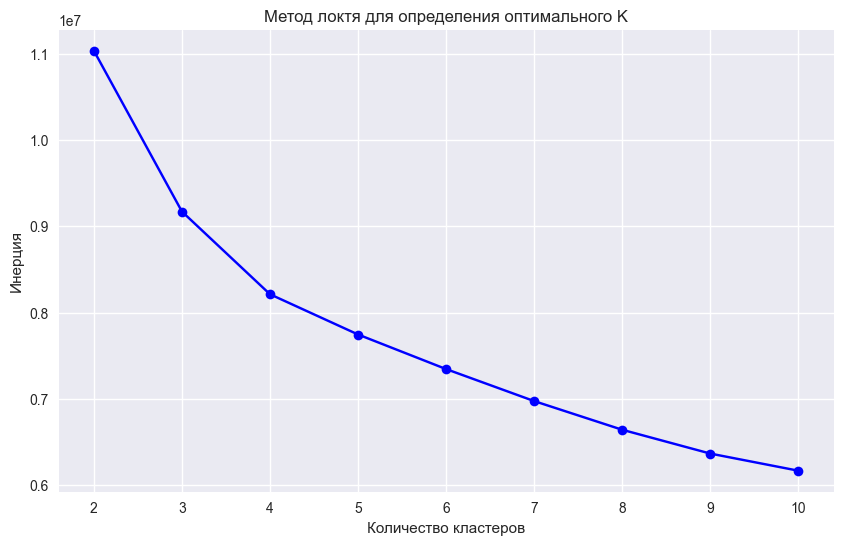

🎯 Оптимальное количество кластеров: 5


In [16]:
# Метод локтя
print("Определение оптимального количества кластеров...")

inertia = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, init='k-means++', n_init=10)
    kmeans.fit(scaled_df)
    inertia.append(kmeans.inertia_)
    print(f"K={k}, inertia={kmeans.inertia_:.2f}")

# Визуализация
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, 'bo-')
plt.xlabel('Количество кластеров')
plt.ylabel('Инерция')
plt.title('Метод локтя для определения оптимального K')
plt.grid(True)
plt.show()

# Автоматическое определение оптимального K
inertia_diff = np.diff(inertia)
if len(inertia_diff) > 1:
    inertia_diff_ratio = [inertia_diff[i] / inertia_diff[i+1] for i in range(len(inertia_diff)-1)]
    optimal_k = k_range[np.argmax(inertia_diff_ratio) + 2]
else:
    optimal_k = 3

print(f"🎯 Оптимальное количество кластеров: {optimal_k}")

Обучение K-Means с 5 кластерами...
✓ Кластеризация завершена

Распределение по кластерам:
cluster
0    333655
1    298173
2     45690
3    168506
4     90595
Name: count, dtype: int64


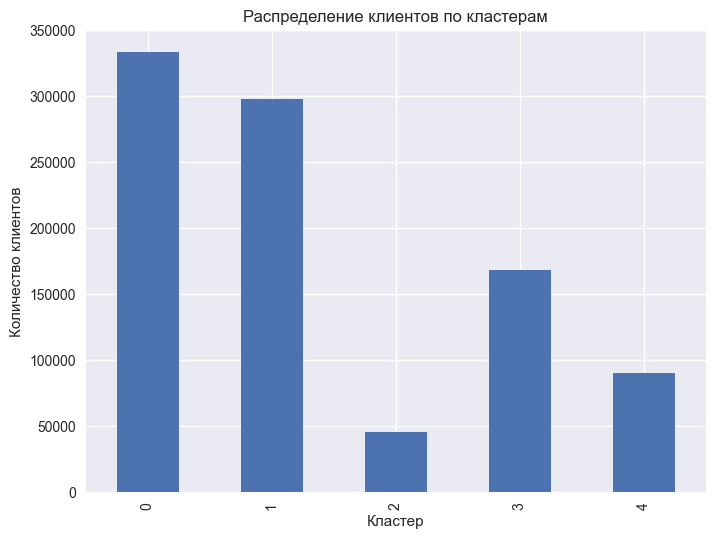

In [17]:
# Кластеризация
print(f"Обучение K-Means с {optimal_k} кластерами...")

final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, init='k-means++', n_init=10)
clusters = final_kmeans.fit_predict(scaled_df)

# Добавляем кластеры к данным
client_features['cluster'] = clusters
scaled_df['cluster'] = clusters

print("✓ Кластеризация завершена")
print("\nРаспределение по кластерам:")
cluster_distribution = client_features['cluster'].value_counts().sort_index()
print(cluster_distribution)

# Визуализация распределения
plt.figure(figsize=(8, 6))
cluster_distribution.plot(kind='bar')
plt.title('Распределение клиентов по кластерам')
plt.xlabel('Кластер')
plt.ylabel('Количество клиентов')
plt.show()

Визуализация кластеров...


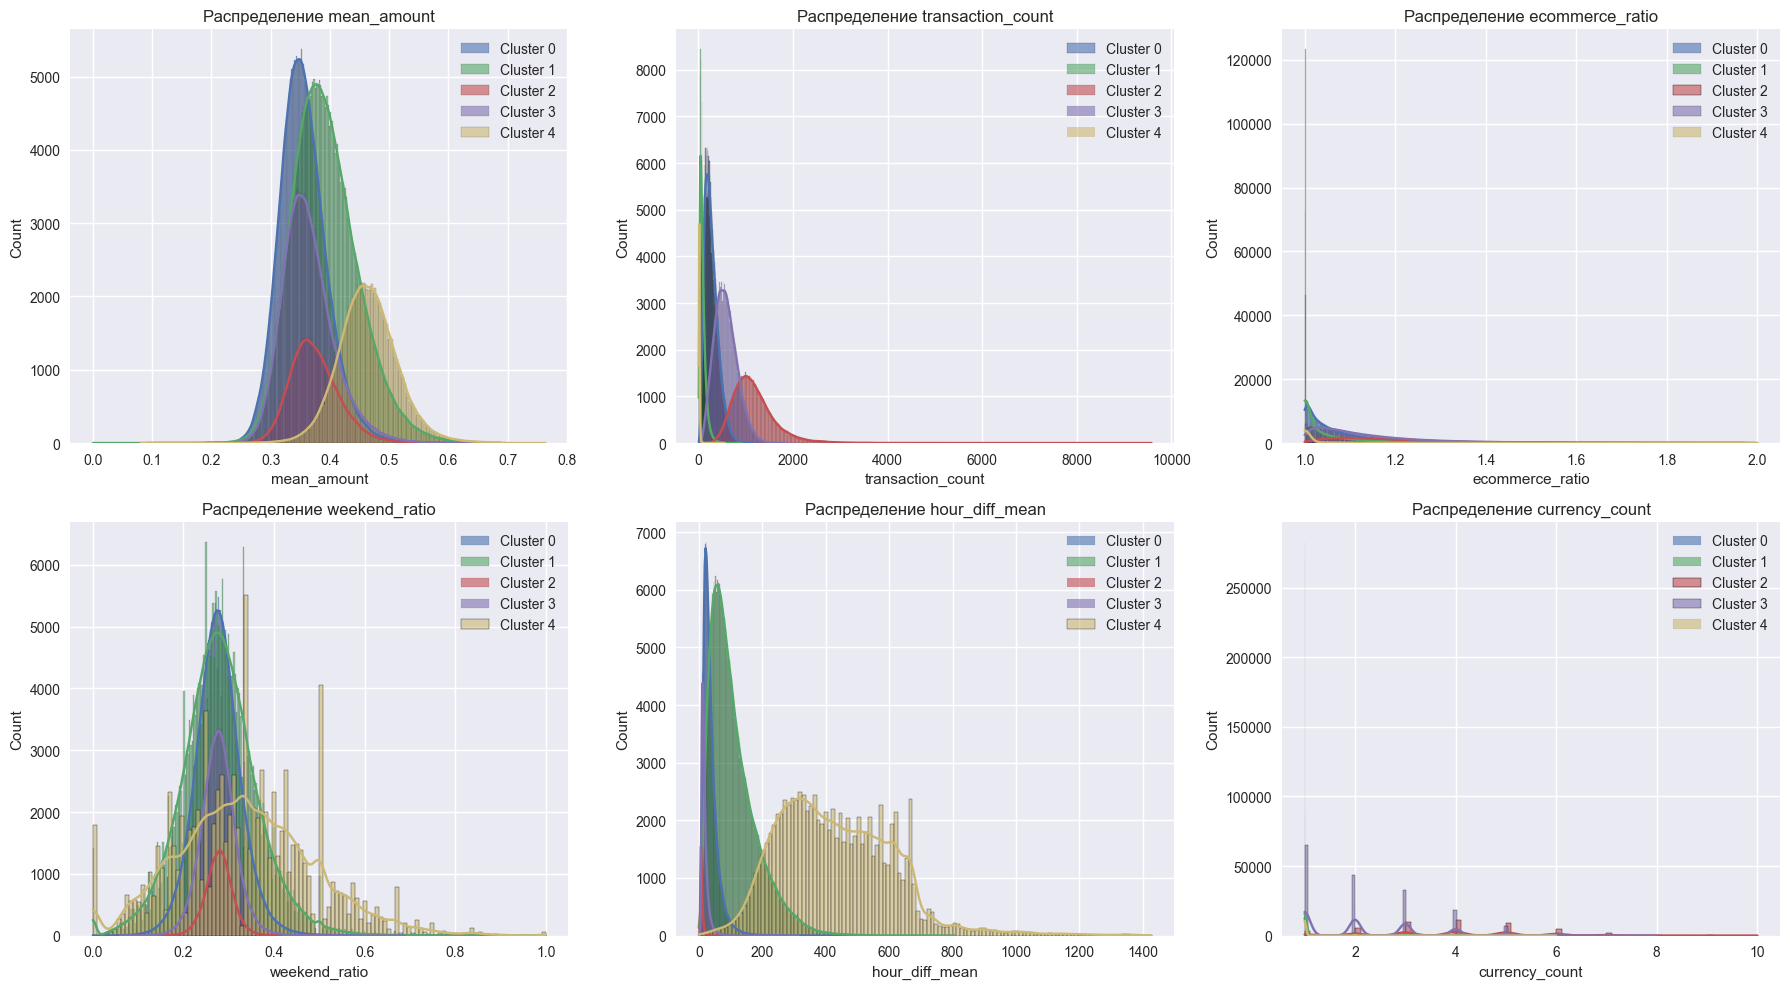

In [18]:
# Визуализация распределения признаков по кластерам
print("Визуализация кластеров...")

# Выбираем ключевые признаки для визуализации
key_features = [col for col in ['mean_amount', 'transaction_count', 'ecommerce_ratio', 
                               'weekend_ratio', 'hour_diff_mean', 'currency_count'] 
                if col in client_features.columns]

n_cols = 3
n_rows = (len(key_features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
if n_rows == 1:
    axes = [axes] if n_cols == 1 else axes
else:
    axes = axes.flatten()

for i, feature in enumerate(key_features):
    if i < len(axes):
        for cluster in sorted(client_features['cluster'].unique()):
            cluster_data = client_features[client_features['cluster'] == cluster][feature]
            sns.histplot(cluster_data, ax=axes[i], label=f'Cluster {cluster}', alpha=0.6, kde=True)
        axes[i].set_title(f'Распределение {feature}')
        axes[i].legend()

# Скрываем пустые subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()